<a href="https://colab.research.google.com/github/hasselmanneduarda-wq/bioestat-2026/blob/main/Tarefa04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tarefa 4
###André Luiz Leal ()
###Maria Eduarda Hasselmann (17100517)
###Raissa Lara Pinheiro (16939302)


####Fonte utilizada para a base de dados:
FISHER, R. A. The use of multiple measurements in taxonomic problems. Annals of Eugenics, v. 7, n. 2, p. 179–188, 1936.
FISHER, R. A. Iris [dataset]. Irvine: University of California, Irvine, UCI Machine Learning Repository, 1936. Disponível em: https://archive.ics.uci.edu/dataset/53/iris. DOI: https://doi.org/10.24432/C56C76. Acesso em: 16 ago. 2026.

####Fonte utilizada para referência teórica
MORETTIN, Pedro A.; BUSSAB, Wilton O. Estatística básica. 9. ed. São Paulo: Saraiva, 2019. 554 p.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

dados = pd.read_excel("tarefa4.xlsx")


dados.head()

,Espécies,Comprimento da sépala,Largura da sépala,Comprimento da pétala,Largura da pétala
0,Iris-setosa,5.1,3.5,1.4,0.2
1,Iris-setosa,4.9,3.0,1.4,0.2
2,Iris-setosa,4.7,3.2,1.3,0.2
3,Iris-setosa,4.6,3.1,1.5,0.2
4,Iris-setosa,5.0,3.6,1.4,0.2


## Conceitos estatísticos utilizados

Para Morettin e Bussab (2019), medidas de posição e de dispersão podem ser utilizadas para analisar uma distribuição de um conjunto de dados. Os conceitos encontrados no livro que se adequam a atividade são os quartis, mediana, amplitude interquartílica, boxplot e observações atípicas.

Os quartis são medidas de posição que dividem um conjunto ordenado em quatro partes. O primeiro quartil, ou Q1, corresponde a aproximadamente 25% dos dados.O segundo quartil, Q2 corresponde à mediana,  que divide o conjunto de dados ao ao meio (50%). O terceiro quartil, Q3 representa o valor que une 75% das observações.

A mediana é uma medida de posição central, depois de ordenar cada observação, ela divide os dados onde metade dos valores fica abaixo dela e metade acima.

A amplitude interquartílica (AIQ) é uma medida de dispersão calculada pela diferença entre o terceiro e o primeiro quartil:

**AIQ = Q3 − Q1**

Ela representa a amplitude ocupada pelos 50% centrais das observações e apresenta a vantagem de não ser muito influenciada por valores extremos.

O **boxplot**, ou diagrama de caixa, é uma representação gráfica que se baseia nos quartis. A caixa compreende os valores entre Q1 e Q3, representando os 50% centrais dos dados. A linha localizada dentro da caixa representa a mediana. Além disso, o gráfico em boxpot também possui extensões chamadas de bigodes, e pode evidenciar possíveis observações atípicas representando os limites superiores e inferiores da variação dos dados e estendendo os valores máximos e mínimos do conjunto de dadados.

EEsse conceitos apresentdos podem ser aplicados à variável do comprimento da pétala em centímetros, das três espécies presentes na base de dados Iris.


In [ ]:
petala = dados["Comprimento da pétala"]


petala = petala.dropna()

print("Número de observações analisadas:", len(petala))

Número de observações analisadas: 150


In [ ]:

Q1 = petala.quantile(0.25)
Q2 = petala.quantile(0.50)
Q3 = petala.quantile(0.75)

AIQ = Q3 - Q1

print(f"Primeiro quartil (Q1): {Q1:.2f} cm")
print(f"Segundo quartil (Q2 - Mediana): {Q2:.2f} cm")
print(f"Terceiro quartil (Q3): {Q3:.2f} cm")
print(f"Amplitude interquartílica (AIQ): {AIQ:.2f} cm")

Primeiro quartil (Q1): 1.60 cm
Segundo quartil (Q2 - Mediana): 4.35 cm
Terceiro quartil (Q3): 5.10 cm
Amplitude interquartílica (AIQ): 3.50 cm


In [ ]:
limite_inferior = Q1 - 1.5 * AIQ
limite_superior = Q3 + 1.5 * AIQ

print(f"Limite inferior: {limite_inferior:.2f} cm")
print(f"Limite superior: {limite_superior:.2f} cm")

Limite inferior: -3.65 cm
Limite superior: 10.35 cm


In [ ]:
outliers = petala[
    (petala < limite_inferior) |
    (petala > limite_superior)
]

print("Número de observações atípicas:", len(outliers))

print("\nValores atípicos:")
print(outliers)

Número de observações atípicas: 0

Valores atípicos:
Series([], Name: Comprimento da pétala, dtype: float64)


## Interpretação dos quartis

Foram analisadas 150 observações referentes ao comprimento das pétalas das flores presentes na base Iris.

O primeiro quartil (Q1) foi de **1,60 cm**. Demonstrando que aproximadamente 25% das flores analisadas apresentam comprimento de pétala menor ou igual a 1,60 cm.

O segundo quartil (Q2), que representa a mediana, foi de 4,35 cm. Ou seja, aproximadamente 50% das flores apresentam comprimento de pétala menor ou igual a 4,35 cm, enquanto aproximadamente 50% apresentam valores maiores ou iguais a esse valor.

O terceiro quartil (Q3) foi de 5,10 cm, indicando que aproximadamente 75% das observações apresentam comprimento de pétala menor ou igual a esse valor e aproximadamente 25% apresentam valores maiores que isso.

A amplitude interquartílica (AIQ) encontrada foi de 3,50 cm, calculada por:

AIQ = 5,10 − 1,60 = 3,50 cm

Então, os 50% no centro das observações encontram-se entre 1,60 cm e 5,10 cm.
É importante considerar que a base reúne três espécies distintas de Iris. Concluindo que parte da variação encontrada no comprimento das pétalas está relacionada às diferenças morfológicas naturais entre *Iris setosa*, *Iris versicolor* e *Iris virginica*.


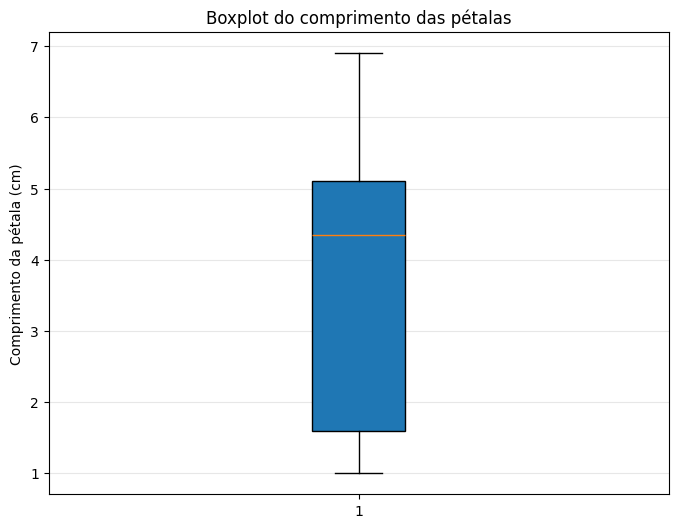

In [ ]:

plt.figure(figsize=(8, 6))

plt.boxplot(
    petala,
    patch_artist=True
)

plt.title("Boxplot do comprimento das pétalas")
plt.ylabel("Comprimento da pétala (cm)")

plt.grid(axis="y", alpha=0.3)

plt.show()

<Figure size 900x600 with 0 Axes>

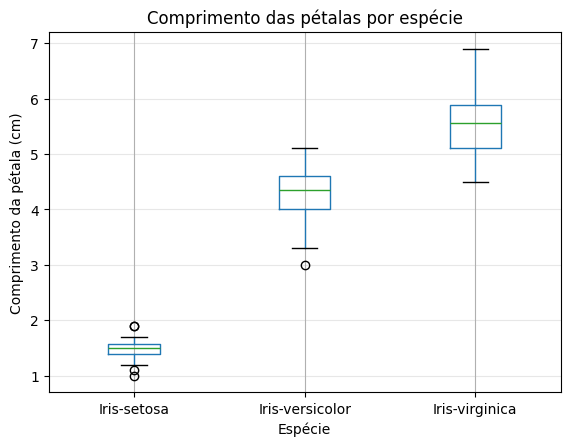

In [ ]:

if 'Espécies ' in dados.columns:
    dados.rename(columns={'Espécies ': 'Species'}, inplace=True)

plt.figure(figsize=(9, 6))

dados.boxplot(
    column="Comprimento da pétala",
    by="Species"
)

plt.title("Comprimento das pétalas por espécie")
plt.suptitle("")
plt.xlabel("Espécie")
plt.ylabel("Comprimento da pétala (cm)")

plt.grid(axis="y", alpha=0.3)

plt.show()

## Interpretação do boxplot

O boxplot geral permite visualizar a distribuição do comprimento das pétalas das 150 flores analisadas.

A caixa do gráfico é delimitada pelo primeiro quartil (**Q1 = 1,60 cm**) e pelo terceiro quartil (**Q3 = 5,10 cm**), representando os 50% centrais das observações. A linha presente no interior da caixa corresponde à mediana, de **4,35 cm**.

É possível observar uma grande variação no comprimento das pétalas. Porém, essa variação deve ser interpretada levando em consideração que a base de dados agrupa indivíduos que pertencem a três espécies distintas.

O boxplot separado por espécie evidencia melhor essa característica. A ***Iris setosa*** apresenta os menores comprimentos de pétala, enquanto a ***Iris versicolor*** apresenta valores intermediários e a ***Iris virginica*** apresenta, em geral, os maiores comprimentos.

Dessa forma, o comprimento da pétala apresenta diferenças importantes entre as três espécies e apresenta uma característica morfológica relevante para diferenciar uma das outras.

A comparação dos dois gráficos também demonstra a importância do contexto biológico na interpretação das informações. Uma grande variabilidade observada ao analisar todos os indivíduos agrupados pode resultar não apenas das diferenças entre indivíduos, mas também da presença de grupos biologicamente distintos no conjunto de dados.


In [ ]:
petala = dados["Comprimento da pétala"]
petala = petala.dropna()

print("Número de observações analisadas:", len(petala))

Número de observações analisadas: 150


In [ ]:
Q1 = petala.quantile(0.25)
Q2 = petala.quantile(0.50)
Q3 = petala.quantile(0.75)

AIQ = Q3 - Q1

print(f"Primeiro quartil (Q1): {Q1:.2f} cm")
print(f"Segundo quartil (Q2): (Q2 - Mediana): {Q2:.2f} cm")
print(f"Terceiro quartil (Q3): {Q3:.2f} cm")
print(f"Amplitude interqualítica (AIQ) (Q3): {AIQ:.2f} cm")



Primeiro quartil (Q1): 1.60 cm
Segundo quartil (Q2): (Q2 - Mediana): 4.35 cm
Terceiro quartil (Q3): 5.10 cm
Amplitude interqualítica (AIQ) (Q3): 3.50 cm


In [ ]:
limite_inferior = Q1 - 1.5 * AIQ
limite_superior = Q3 + 1.5 * AIQ

print(f"Limite inferior: {limite_inferior:.2f} cm")
print(f"Limite superior: {limite_superior:.2f} cm")

outliers = petala[
    (petala < limite_inferior) |
        (petala > limite_superior)
        ]
print("Número de observações atípicas:", len(outliers))

Limite inferior: -3.65 cm
Limite superior: 10.35 cm
Número de observações atípicas: 0


## Como determinamos se há observações atípicas em uma base de dados?

Uma forma de determinar a existência de potenciais observações atípicas é utilizar a **amplitude interquartílica (AIQ)**.

Primeiramente, é calculado:

**AIQ = Q3 − Q1**

Em seguida, são definidos um limite inferior e um limite superior:

**Limite inferior = Q1 − 1,5 × AIQ**

**Limite superior = Q3 + 1,5 × AIQ**

As observações que apresentam valores inferiores ao limite inferior ou superiores ao limite superior são consideradas como **potenciais observações atípicas**.

Para os dados analisados na tabela, foram obtidos os seguintes limites:

**Limite inferior = −3,65 cm**

**Limite superior = 10,35 cm**

Como nenhum dos comprimentos de pétala das 150 flores está fora desses limites, não foram identificadas observações atípicas na análise conjunta da variável comprimento da pétala.

Porém, classificar estatisticamente uma observação como atípica não significa que ela seja necessariamente incorreta ou que deve ser ignorada da base. No estudo da vida, valores extremos podem representar variações naturais entre organismos, diferenças genéticas, condições ambientais ou diferenças entre grupos e espécies. Também podem, eventualmente, ser consequência de erros de medição ou registro.

Por isso, a identificação matemática de uma potencial observação atípica deve ser acompanhada de uma análise do contexto biológico e do processo de coleta dos dados antes de qualquer decisão sobre sua exclusão.